In [1]:
import h5py as h5 
import h5flow 
import matplotlib.pyplot as plt
import numpy as np
import os 
plt.style.use('../../utils/dune.mplstyle')

# Example 01: Getting "good" PMT triggers

In this example we explore how to pick "signal-like" triggers in AmBe flow files. The selection of good triggers uses FPrompt and pulse width as the discriminating variables. The values to perform the trigger selection have been obtained by Angela White. 

In [2]:
source_in_file = "/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_light/source_ambe_bin2/one_trig_32us_window/mpd_run_data_rctl_615_p85.FLOW.hdf5"

In `PMT_analysis_utils`, there is a function `PMT_wvfm_selection` that applies the trigger cut to the stack of waveforms obtained from an AmBe flow file. Below is an example on how to use that function. Note that in this case, we open the file with `h5py`, but it also works if you get the waveform stack using `h5flow`. 

In [3]:
# Using just h5py
source_h5_file = h5.File(source_in_file,"r")
light_ev = source_h5_file['light/events/data']
waveforms = source_h5_file['light/wvfm/data']['samples']
print(f"Number of light events {len(light_ev)}")

from PMT_analysis_utils import PMT_wvfm_selection
masked_events = PMT_wvfm_selection(waveforms,width=31)
print(f"Fraction of good triggers: {len(masked_events[masked_events==1])/len(masked_events)}")


Number of light events 3488
Fraction of good triggers: 0.4194380733944954


In addition, there is a function `classify_triggers_single` that works for files with prompt triggers only. This function accepts as an argument a flow file opened with h5flow, and returns the ids of the good triggers and the ids of the bad triggers. Note that this function calls the previous `PMT_wvfm_selection` function.

In [4]:
# We export the function to get the ids of the good triggers 
source_h5flow_file = h5flow.data.H5FlowDataManager(source_in_file,'r')
from PMT_analysis_utils import classify_triggers_single
good_triggers_ids, bad_triggers_ids = classify_triggers_single(source_h5flow_file,debug=False)
print(f"First 10 good triggers: {good_triggers_ids[:10]}")
print(f"First 10 bad triggers: {bad_triggers_ids[:10]}")

# Get your good and bad waveforms 
good_wvfms = source_h5flow_file['light/wvfm',good_triggers_ids]['samples']
bad_wvfms = source_h5flow_file['light/wvfm',bad_triggers_ids]['samples']

Running with all the 3488 events
Fraction of good triggers 0.4194380733944954
First 10 good triggers: [ 2  9 13 15 16 20 22 26 27 28]
First 10 bad triggers: [ 0  1  3  4  5  6  7  8 10 11]


We check the shape of the obtained waveform stack: (#Events,#ADC,#Channel,#Samples)

In [5]:
good_wvfms.shape

(1463, 8, 64, 2000)

The ADC and channel numbers corresponding to the AmBe PMT trigger are 0 and 16 respectively

In [6]:
ADC_NUM = 0 
CHAN_NUM = 16 

In [7]:
# Get only PMT waveforms
PMT_wvfms_good = -1*good_wvfms[:,ADC_NUM,CHAN_NUM,:]
PMT_wvfms_bad = -1*bad_wvfms[:,ADC_NUM,CHAN_NUM]
print(PMT_wvfms_good.shape)

(1463, 2000)


Finally, we plot one of the good waveforms using another helper function. Also, we compare the maximum of the good PMT triggers v/s the bad triggers. We observe a clear separation due to the cuts implemented in the selection function. 

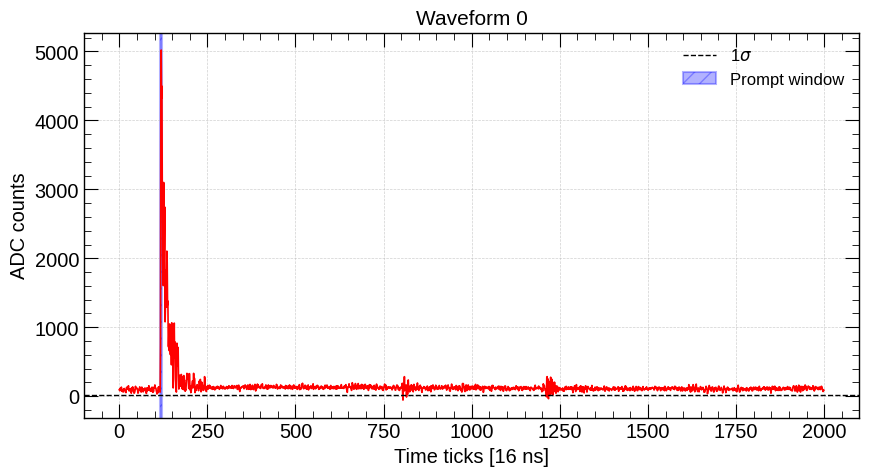

In [8]:
from PMT_analysis_utils import make_waveform_plot
make_waveform_plot(PMT_wvfms_good[0],"start",0,voltage=False)

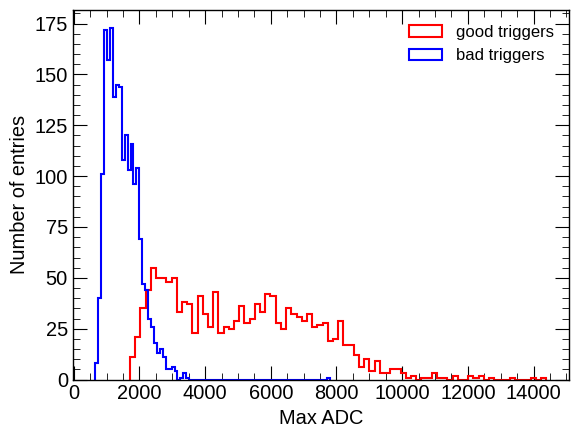

In [9]:
plt.hist(np.max(PMT_wvfms_good,axis=1),bins=80,histtype='step',color='red',label='good triggers')
plt.hist(np.max(PMT_wvfms_bad,axis=1),bins=80,histtype='step',color='blue',label='bad triggers')
plt.legend()
plt.xlabel("Max ADC")
plt.ylabel("Number of entries")
plt.show()

# Example 02: Prompt and Delayed Triggers

In this example we focus in files containing both prompt and delayed triggers. The way these triggers are arranged in a file, is that given one entry corresponding to a prompt trigger, the next entry will be its corresponding delayed trigger.

In [10]:
test_file = "/global/cfs/cdirs/dune/www/data/2x2/reflows_run2/v0/flow/ColdOperations/data/2025_Operations_Cold/source/AmBe_1112/packet-0060116-2025_11_12_18_17_10_CST.FLOW_v0.hdf5"
h5_file = h5flow.data.H5FlowDataManager(test_file,'r')
TRIGGER_PERIOD = 291

The helper function `check_first_trig` takes as an argument an input h5flow file, and the corresponding period between the prompt and delayed trigger. In this example that period is 291 microseconds. The function compares the time between the first and second entry. If this time difference is equal to the trigger period, this means that the first entry is a prompt trigger and therefore, all the even entries (0,2,4,...) are prompt triggers. On the other hand, if this difference does not match with the period between triggers, the first trigger corresponds to a delayed trigger. In this case, the prompt triggers will correspond to the odd entries in the file. 

In [11]:
from PMT_analysis_utils import check_first_trig
first_trig_category = check_first_trig(h5_file,TRIGGER_PERIOD)

Time difference bt second and first trigger 291.072
Rounded time difference: 291
The first trigger is a prompt trigger


Now we know that in this file, even entries correspond to prompt triggers, whereas odd entries to delayed triggers. We can use the function `classify_triggers` to obtain the good and bad prompt triggers in this file. Using the h5flow we can also get the charge events associated to the good pmt triggers. 

In [12]:
from PMT_analysis_utils import classify_triggers
# Since this is an example, we run in debug mode (last argument)
good_triggers, bad_triggers = classify_triggers(h5_file,"even",True)

# Get good triggers 
light_events = h5_file['light/events',good_triggers]
light_wvfms = h5_file['light/wvfm',good_triggers]['samples']
charge_events = h5_file['light/events','charge/events',good_triggers]

# Get bad triggers 
bad_light_events = h5_file['light/events',bad_triggers]
bad_light_wvfms = h5_file['light/wvfm',bad_triggers]['samples']
bad_charge_events = h5_file['light/events','charge/events',bad_triggers]


Running in debug mode with 6010 events (10 percent)


/pscratch/sd/l/lmlepin/clean_repo/2x2_neutron_sources/AmBe/light/PMT_analysis_utils.py:271: RuntimeWarning: divide by zero encountered in divide
  fprompt_mask = ((fast_light/all_light) > fprompt_min)*((fast_light/all_light) < fprompt_max)


Fraction of good trigger 0.42895174708818634


In [13]:
light_wvfms.shape

(1289, 8, 64, 600)

In [14]:
# Get only PMT waveforms
prompt_PMT_wvfms_good = -1*light_wvfms[:,ADC_NUM,CHAN_NUM,:]
prompt_PMT_wvfms_bad = -1*bad_light_wvfms[:,ADC_NUM,CHAN_NUM]
print(prompt_PMT_wvfms_good.shape)

(1289, 600)


Same as in example 01, we plot one good waveform, and make the max(waveform) comparison at the end. 

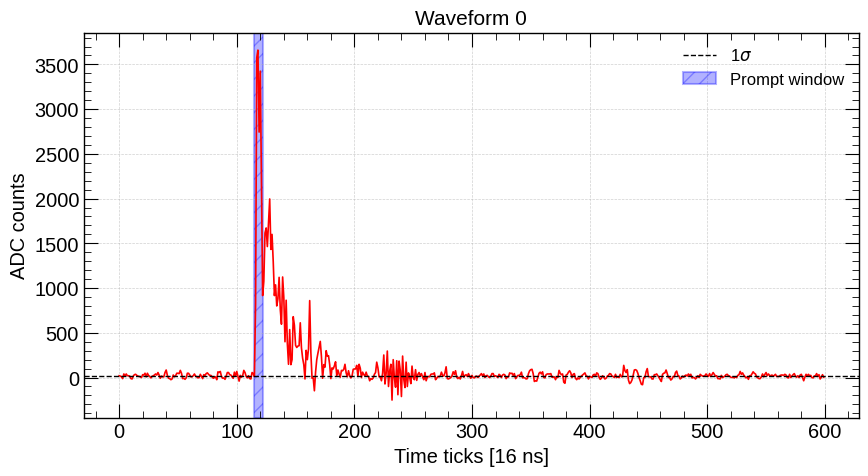

In [15]:
make_waveform_plot(prompt_PMT_wvfms_good[0],"Prompt",0,voltage=False)

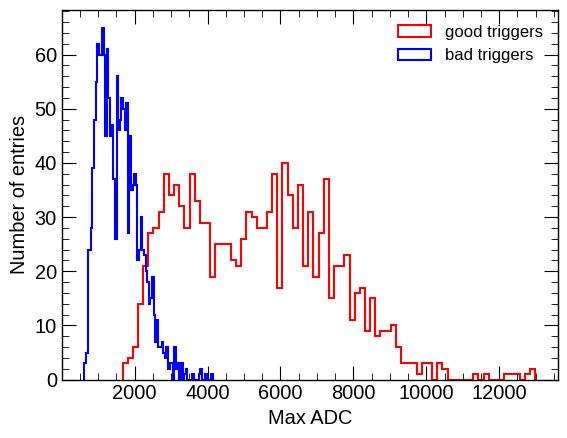

In [16]:
plt.hist(np.max(prompt_PMT_wvfms_good,axis=1),bins=80,histtype='step',color='red',label='good triggers')
plt.hist(np.max(prompt_PMT_wvfms_bad,axis=1),bins=80,histtype='step',color='blue',label='bad triggers')
plt.legend()
plt.xlabel("Max ADC")
plt.ylabel("Number of entries")
plt.show()